# MBES Detrending - Transect 057

Shows how to detrend the MBES data such that you can see the local variations eg rock or bombs.

**Note:** This notebook uses `config.MBES_GEOTIFF_057` (geotiff_2.tif) which is specific to transect 057, instead of the full MBES coverage (`config.MBES_GEOTIFF`).

In [1]:
import sys
from pathlib import Path

# Find mjosa_code root by looking for utils folder
current = Path.cwd()
while current != current.parent:
    if (current / "utils" / "mbes").exists():
        mjosa_code_root = current
        break
    current = current.parent
else:
    # Fallback: assume we're in notebooks/ or notebooks/mbes/
    mjosa_code_root = (
        Path.cwd().parent.parent if Path.cwd().name == "mbes" else Path.cwd().parent
    )

sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code
from utils.mbes import MBESDetrender, AutoTuneMBES, ScoreWeights
from utils.common import config
import matplotlib.pyplot as plt

plt.ion()
print(f"✅ Imports successful! mjosa_code root: {mjosa_code_root}")

✅ Imports successful! mjosa_code root: e:\mjosa_complete\gref4hsi\mjosa_code


In [2]:
# Use transect-specific MBES GeoTIFF (geotiff_2.tif) from config
tif_path = config.MBES_GEOTIFF_057

print(f"Using GeoTIFF: {tif_path}")
print(f"File exists: {tif_path.exists()}")

Using GeoTIFF: e:\mjosa_complete\data\anxilliary\EIVA\geotiff_2.tif
File exists: True


## Manually tune the parameters

## Option: NED coordinates (local frame, relative to origin)

Plots will show coordinates relative to the NED origin from config.

**Note:** UHI footprint is automatically loaded from config - no need to pass UHI parameters explicitly!

In [3]:
# %matplotlib qt

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)
✅ UHI footprint loaded! Shape: E=(990, 968), N=(990, 968), mask=(990, 968)
   Valid pixels: 958320
✅ Loaded full cube: (2462, 968, 210) (T × S × B)
✅ UHI footprint loaded! Shape: E=(990, 968), N=(990, 968), mask=(990, 968)
   Valid pixels: 958320


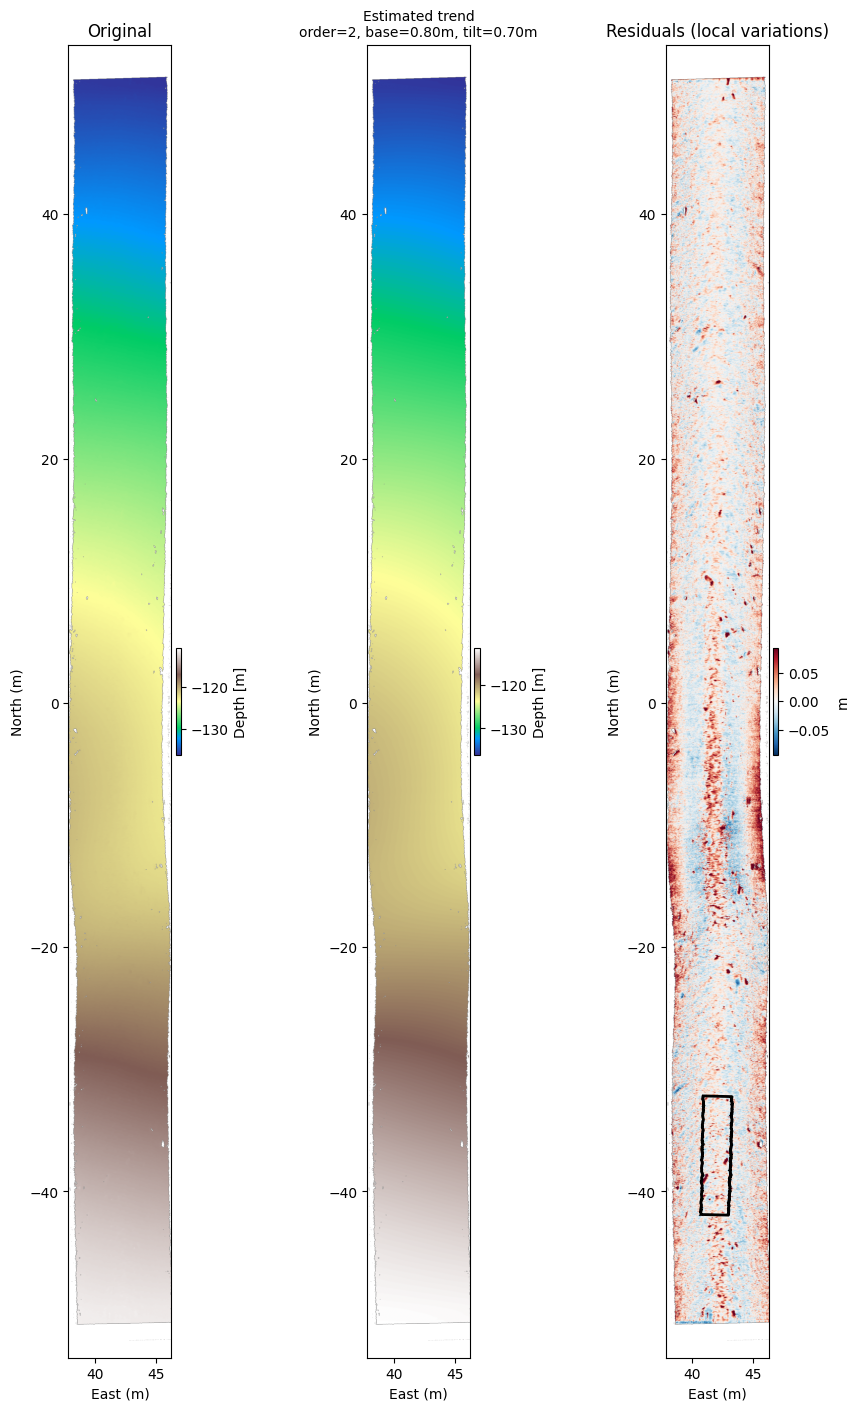

✅ Done! UHI footprint loaded and displayed as black outline.


In [4]:
# Clean and simple! UHI footprint loaded automatically from config
mb_ned = MBESDetrender(
    tif_path,
    coord_system="ned",
    ned_origin=(config.LON0, config.LAT0, config.H0),
    epsg_utm=config.EPSG_UTM,
    epsg_geo=config.EPSG_GEOGRAPHIC,
)

# Load MBES data and UHI footprint
mb_ned.load()

# Check if footprint loaded
if mb_ned.uhi_footprint is not None:
    E, N, mask = mb_ned.uhi_footprint
    print(
        f"✅ UHI footprint loaded! Shape: E={E.shape}, N={N.shape}, mask={mask.shape}"
    )
    print(f"   Valid pixels: {mask.sum()}")
else:
    print("❌ UHI footprint NOT loaded!")
    print(f"   transect_folder: {mb_ned.uhi_transect_folder}")
    print(f"   uhi_files: {mb_ned.uhi_files}")
    print(f"   track_range: {mb_ned.uhi_track_range}")

# Detrend
mb_ned.detrend(
    order_x=3,
    smooth_baseline_m=0.80,
    smooth_tilt_m=0.70,
    smooth_center_m=1.0,
    robust=True,
    central_frac=0.8,
)

# Plot with UHI footprint overlay
fig = mb_ned.plot_triptych(footprint_style="outline", show=True)
print("✅ Done! UHI footprint loaded and displayed as black outline.")

# 📖 Documentation: MBES Visualization Methods

This notebook uses three visualization methods from `MBESDetrender`:

---

## **Figure 1: Triptych (Cell 7)** — `plot_triptych()`

**What You're Looking At:**

Three side-by-side maps of the seafloor:

1. **Left panel - Original Bathymetry:** 
   - Color shows seafloor depth (brown=deeper, blue=shallower)
   - You see a diagonal stripe of bathymetry data
   - Depth range: ~120-122 meters
   - Notice the gradual slope from top-left to bottom-right

2. **Middle panel - Estimated Trend:** 
   - Same color scheme as left panel
   - Shows the SMOOTH version of the bathymetry (regional slope only)
   - This is what gets subtracted out
   - All the small bumps and dips are gone

3. **Right panel - Residuals (WHAT YOU CARE ABOUT):**
   - **Red-white-blue colormap** (NOT terrain colors)
   - **Red spots** = things sticking UP (rocks, munitions, boulders)
   - **Blue spots** = things going DOWN (pits, holes, scour marks)  
   - **White/light colors** = flat seafloor (nothing interesting)
   - **Black outline** = where your hyperspectral camera saw
   - Typical range: ±0.05 to ±0.15 meters

**Why Three Panels:**
Shows the math: Original - Trend = Residuals. The residuals panel is where you find targets!

**Parameters Used:**
```python
fig = mb_ned.plot_triptych(
    footprint_style="outline",  # Black outline only
    show=True
)
```

---

## **Figure 2: Components (Cell 10)** — `plot_components()`

**What You're Looking At:**

Four line plots showing how the polynomial coefficients change along the vehicle's path (north-south):

1. **Top-left - A(y) Baseline:** 
   - **X-axis:** Depth in meters (~120-122 m)
   - **Y-axis:** Northing position (inverted, so north=top like a map)
   - **Faint line:** Jittery raw depth for each swath row
   - **Bold line:** Smoothed depth profile (what actually gets used)
   - Shows: How deep the seafloor is as vehicle moves north→south

2. **Top-right - B(y) Tilt:**
   - **X-axis:** Slope in meters/meter (typically small values like ±0.01)
   - **Y-axis:** Northing position
   - **Faint line:** Per-row cross-track tilt (raw)
   - **Bold line:** Smoothed tilt
   - Shows: How much the seafloor tilts left-right across each swath

3. **Bottom-left - C(y) Curvature:**
   - **X-axis:** Curvature coefficient (1/m, very small values)
   - **Y-axis:** Northing position
   - **Faint line:** Raw curvature per row
   - **Bold line:** Smoothed curvature
   - Shows: Cross-track "bowing" or "doming" of each swath

4. **Bottom-right - x̄(y) Swath Center:**
   - **X-axis:** Easting position (meters)
   - **Y-axis:** Northing position  
   - **Faint line:** Median easting of each swath row
   - **Bold line:** Smoothed vehicle path
   - Shows: Where the vehicle was (east-west) as it moved north→south

**What This Tells You:**
- If bold lines are smooth → detrending worked properly
- If faint lines are super jittery → that's noise being removed
- These coefficients define the trend surface that gets subtracted

**Parameters Used:**
```python
fig_components = mb_ned.plot_components(
    figsize=(10, 3), 
    show=True
)
```

---

## **Figure 3: Zoomed Residuals (Cell 13)** — `plot_zoomed_residuals()`

**What You're Looking At:**

A HUGE detailed map showing ONLY the area your hyperspectral camera saw:

- **Background:** MBES residuals (bathymetry anomalies)
- **Red blobs:** Things sticking UP above the smooth seafloor
  - Bright red = ~0.2-0.3 m tall (big munitions, boulders)
  - Pink/salmon = ~0.05-0.15 m tall (small rocks, debris)
- **Blue blobs:** Things going DOWN below the smooth seafloor
  - Dark blue = ~0.1 m deep (pits, craters)
  - Light blue = ~0.02-0.05 m deep (small depressions)
- **White/gray:** Perfectly flat seafloor (±0.02 m = noise level)
- **Jagged black outline:** Exact pixel-perfect boundary of hyperspectral footprint

**How to Use This:**
1. Look for red blobs (elevated features)
2. Check if your hyperspectral data detected something at the same location
3. **Red MBES + HSI detection** = high confidence target!
4. **No red MBES + HSI detection** = might be surface feature only (algae, rust)
5. **Red MBES + no HSI detection** = buried or covered target

**Size Reference:**
- Typical munition: +0.1 to +0.3 m (red)
- Typical rock: +0.05 to +0.15 m (pink to red)
- Noise: ±0.02 m (white/gray)
- Detection threshold: Usually ~±0.05 m

**Parameters Used:**
```python
fig_zoomed = mb_ned.plot_zoomed_residuals(
    outline_color="black",
    outline_width=1.2,
    cmap="RdBu_r",
    figsize=(50, 20),  # Large for high-res inspection
    cbar_fraction=0.006,  # Narrow colorbar
    cbar_pad=0.04,
    cbar_shrink=0.5,  # Half-height colorbar
    show=True,
    use_adjusted=True  # Use alignment-corrected footprint
)
```

**Multi-Sensor Fusion:**
This figure lets you overlay HSI detections on MBES bathymetry to validate targets and reduce false positives.

---

## Detrending Parameters Summary

**What the detrending does:**
- Fits quadratic polynomial to each swath row: $\hat{z}(x) = A + B(x-\bar{x}) + C(x-\bar{x})^2$
- Uses central 80% of beams (reduces edge noise)
- Robust fitting (IRLS) downweights outliers (rocks, munitions)
- Smooths coefficients along-track (Savitzky-Golay filters)
- Subtracts smooth trend to get residuals: $R = Z - \hat{Z}$

**Parameters used in Cell 7:**
```python
mb_ned.detrend(
    order_x=3,              # Quadratic (effective order 2)
    smooth_baseline_m=0.80, # Depth smoothing: 0.8 m
    smooth_tilt_m=0.70,     # Tilt smoothing: 0.7 m
    smooth_center_m=1.0,    # Swath center smoothing: 1.0 m
    robust=True,            # Use IRLS (downweight outliers)
    central_frac=0.8        # Fit central 80% of beams
)
```

**Why these values?**
- **0.8 m baseline smoothing:** Removes depth jitter while preserving gradual changes
- **0.7 m tilt smoothing:** Slightly tighter than baseline (slope varies less)
- **1.0 m center smoothing:** Allows gentle vehicle drift along-track
- **Robust fitting:** Prevents large rocks from biasing trend surface
- **Central 80%:** Avoids noisy outer beams while keeping good coverage

---

In [5]:
# stop

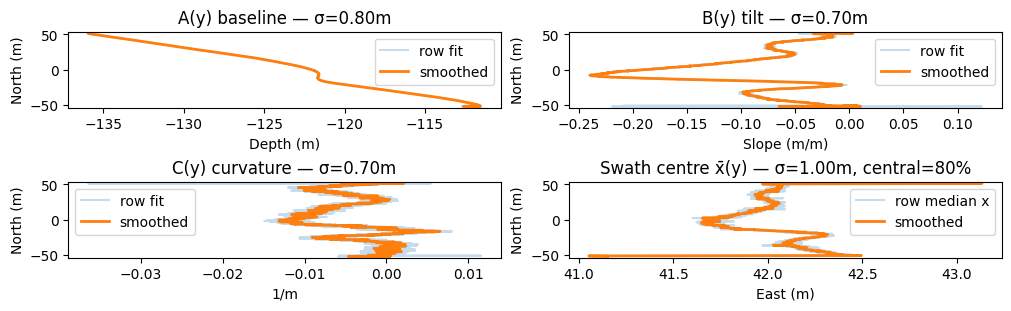

✅ Components plot created!


In [6]:
# Plot the polynomial components (baseline, tilt, curvature, swath center)
# Shows raw per-row fits vs smoothed curves along the northing axis
fig_components = mb_ned.plot_components(figsize=(10, 3), show=True)
print("✅ Components plot created!")

In [7]:
mb_ned.adjust_uhi_alignment(dx=-0.05, dy=-3)

✅ UHI footprint adjusted: dx=-0.050m E, dy=-3.000m N


MBESDetrender(tif_path=WindowsPath('e:/mjosa_complete/data/anxilliary/EIVA/geotiff_2.tif'), nodata_value=9999.0, coord_system='ned', ned_origin=(10.705125, 60.801146, 0.0), epsg_utm=32632, epsg_geo=4326, smooth_baseline_m=0.8, smooth_tilt_m=0.7, smooth_curv_m=0.7, smooth_center_m=1.0, max_row_iters=3, clip_sigma=6.0, central_frac=0.8, uhi_transect_folder=None, uhi_files=None, uhi_track_range=None, data=array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]]), valid_mask=array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False

In [8]:
%matplotlib inline

🎨 MBES plot_zoomed_residuals colorbar range: vmin=-0.0930, vmax=0.0930


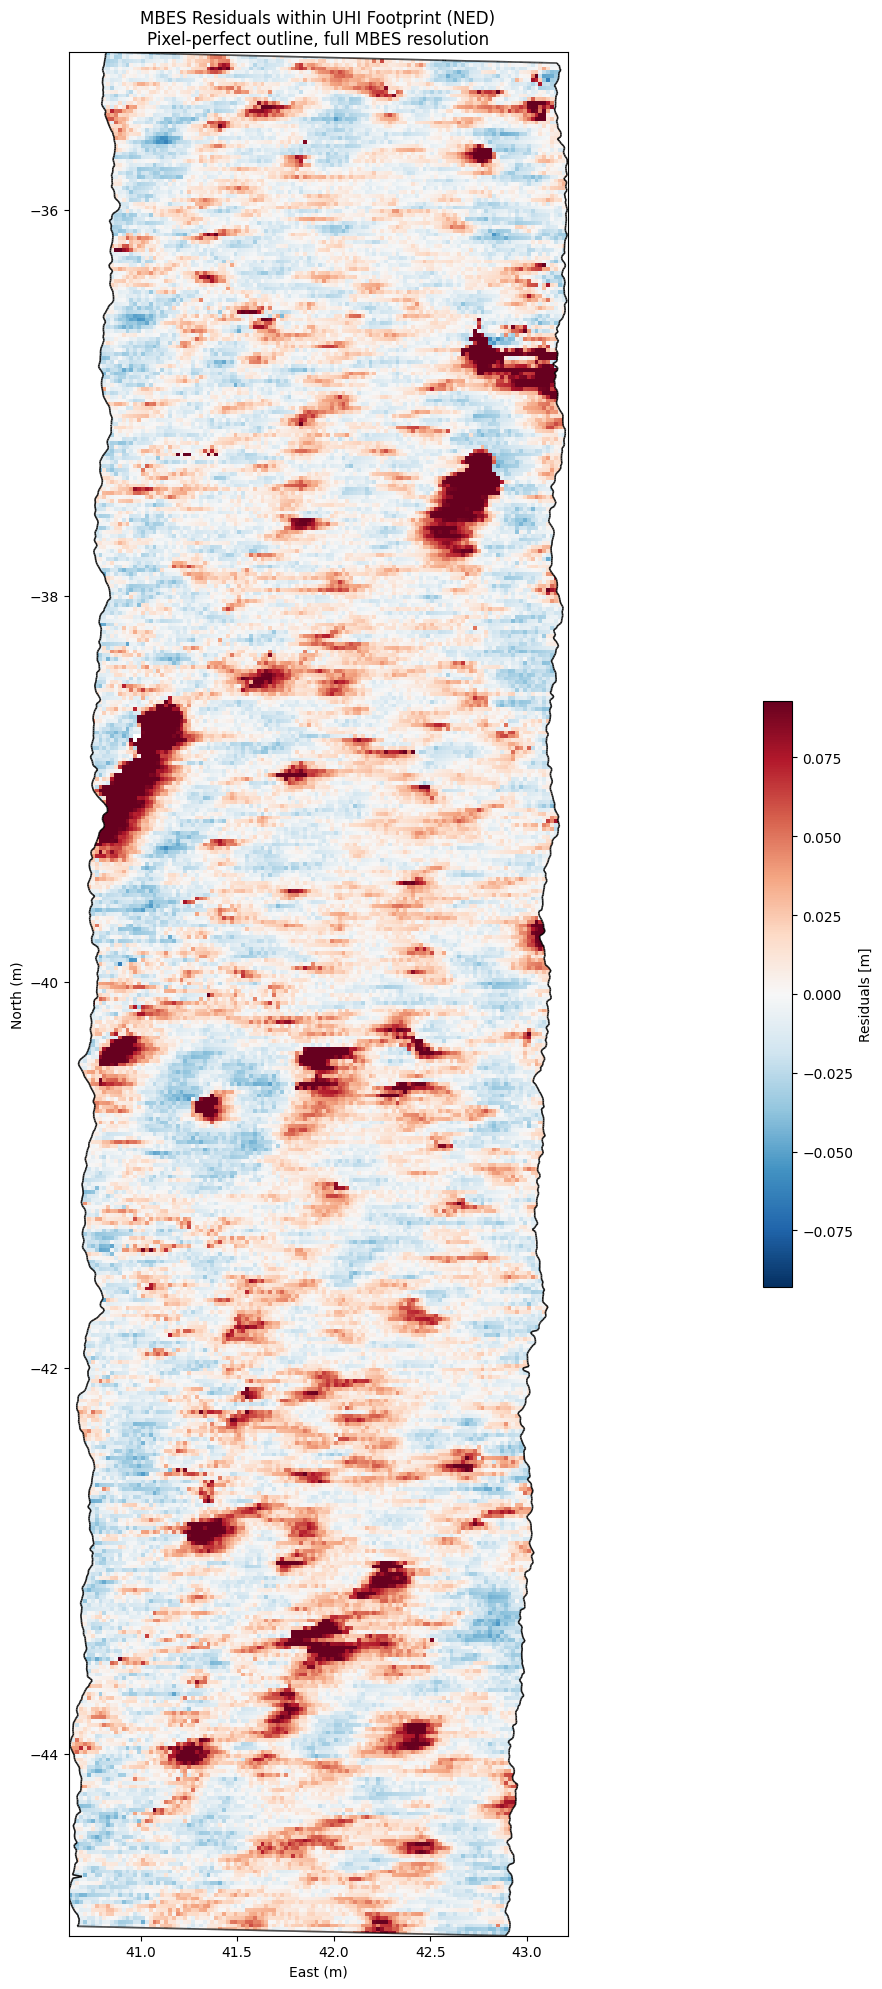

✅ Zoomed residuals plot created!


In [9]:
# NEW: Zoomed-in view of MBES residuals within UHI footprint
# This creates a separte figure showing only the area inside the UHI footprint
# Test with z-scores (default - typical range -6 to +6)

fig_zoomed = mb_ned.plot_zoomed_residuals(
    outline_color="black",
    outline_width=1.2,
    cmap="RdBu_r",
    # figsize=(70, 13.2),
    figsize=(50, 20),
    cbar_fraction=0.006,  # Colorbar width (increase for wider bar)
    cbar_pad=0.04,  # Colorbar padding (increase to move away from plot)
    cbar_shrink=0.5,  # Colorbar height (0.0-1.0, decrease for shorter bar)
    show=True,
    use_adjusted=True,  # Use alignment-adjusted coordinates
    # vmin=-0.145,
    # vmax = 0.11,
)
print("✅ Zoomed residuals plot created!")

In [10]:
# Test with z-scores (default - typical range -6 to +6)
mb_ned.adjust_uhi_alignment(dx=-0.05, dy=-3)

✅ UHI footprint adjusted: dx=-0.050m E, dy=-3.000m N


MBESDetrender(tif_path=WindowsPath('e:/mjosa_complete/data/anxilliary/EIVA/geotiff_2.tif'), nodata_value=9999.0, coord_system='ned', ned_origin=(10.705125, 60.801146, 0.0), epsg_utm=32632, epsg_geo=4326, smooth_baseline_m=0.8, smooth_tilt_m=0.7, smooth_curv_m=0.7, smooth_center_m=1.0, max_row_iters=3, clip_sigma=6.0, central_frac=0.8, uhi_transect_folder=None, uhi_files=None, uhi_track_range=None, data=array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]]), valid_mask=array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False

🎨 MBES plot_zoomed_residuals colorbar range: vmin=-0.0930, vmax=0.0930


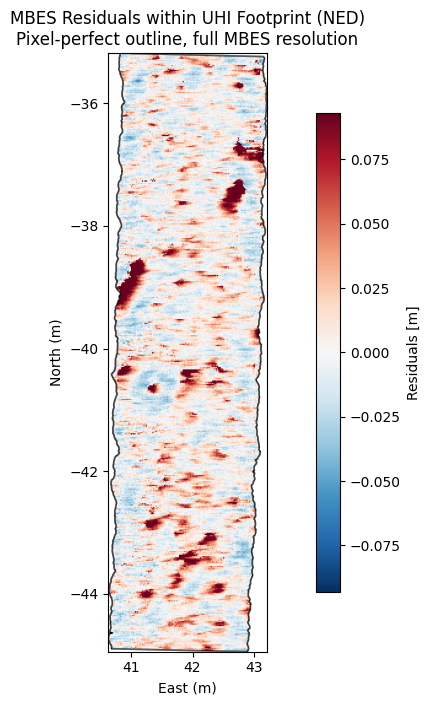

✅ Zoomed residuals plot created!


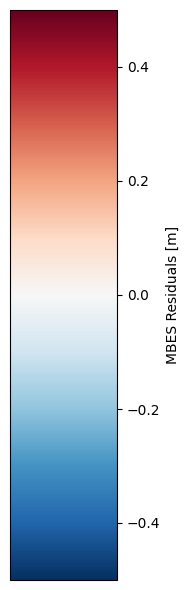

✅ Colorbar plot created!


In [11]:
# Zoomed-in view with adjusted alignment and smaller color scale
fig_zoomed = mb_ned.plot_zoomed_residuals(
    outline_color="black",
    outline_width=1.2,
    cmap="RdBu_r",
    figsize=(9, 7.15),  # Match plot_georef
    # vmin=-0.5,  # Smaller scale like plot_uhi_mbes_comparison
    # vmax=0.5,
    cbar_fraction=0.08,  # Example: Wider colorbar
    cbar_pad=0.06,  # Example: More spacing
    cbar_shrink=0.8,  # Example: Shorter bar (80% height)
    use_adjusted=True,  # Use alignment-adjusted coordinates
    show=True,
)
print("✅ Zoomed residuals plot created!")

# Optional: Plot just the colorbar separately
fig_cbar = mb_ned.plot_colorbar_only(vmin=-0.5, vmax=0.5, show=True)
print("✅ Colorbar plot created!")

🔄 Loading UHI cube data (first time only)...
🔄 Computing illumination correction: rolling (window=1000), strength=1.0


   Processing slits: 100%|██████████| 968/968 [01:57<00:00,  8.26slit/s]



✅ data_corrected ready (rolling (window=1000))
💾 Saving illumination correction to 1 files...
   Dataset: processed/radiance/dataCube_illum_corrected_w1000_s1p00
   ✓ rad_uhi_20241029_115057_5: saved (2462, 968, 210)
   ✓ rad_uhi_20241029_115057_5: saved (2462, 968, 210)
✅ Illumination correction saved to disk
✅ Illumination correction saved to disk
✅ UHI cube cached! Subsequent calls will reuse this data.
✅ UHI cube cached! Subsequent calls will reuse this data.


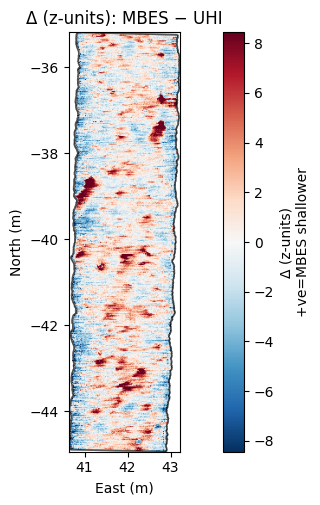

In [12]:
# Create z-score comparison with adjusted alignment
fig = mb_ned.plot_z_normalized_comparison(
    use_adjusted=True,
    figsize=(9, 5.15),
)

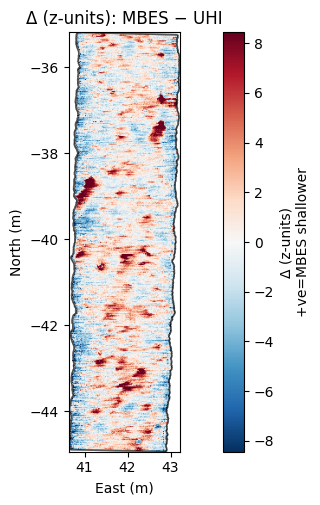

In [13]:
# Create z-score comparison with adjusted alignment
fig = mb_ned.plot_z_normalized_comparison(
    use_adjusted=True,
    figsize=(9, 5.15),
)

In [14]:
stop

NameError: name 'stop' is not defined

In [ ]:
# %matplotlib qt
fig1 = mb_ned.plot_uhi_mbes_comparison(
    use_adjusted=True, normalization_method="zscore", show=True
)

In [ ]:
# %matplotlib qt
fig1 = mb_ned.plot_uhi_mbes_comparison(
    use_adjusted=True, normalization_method="minmax", show=True
)

In [ ]:
stop

In [ ]:
fig_scatter1 = mb_ned.plot_density_scatter(
    use_adjusted=True, normalization_method="zscore", show=True, figsize=(4, 4)
)

In [ ]:
fig = mb_ned.plot_triptych(footprint_style="outline", show=True, use_adjusted=True)

In [ ]:
fig_scatter2 = mb_ned.plot_density_scatter(
    use_adjusted=True, normalization_method="minmax", show=True
)

### Alternative: Generate All Plots at Once

You can also use `plot_all()` to generate all visualizations in one call, including the UHI comparison plots:

In [ ]:
# stop

In [ ]:
# Generate all plots at once (basic + UHI comparison)
# Returns tuple of figures: (triptych, components, heatmap, comparison, scatter)
all_figs = mb_ned.plot_all(show=True, include_uhi_comparison=False)
print(f"✅ Generated {len(all_figs)} figures total!")

# Autotuner - uses optimization to find optimal parameters

In [ ]:
stop run all

### Autotuner Parameter Guide

**Problem:** Default autotuner does 162 iterations (round 1) + 625 iterations (round 2) = **787 total!**

**Solutions to reduce iterations:**

1. **Set `max_rounds=1`** - Skip the refinement round
   - Round 1 only: **162 iterations** (coarse grid search)
   
2. **Use `allowed_orders=(3,)`** - Fix the polynomial order
   - Reduces round 1 to **81 iterations** (only order 3)
   - Reduces round 2 to **625 iterations** (if used)
   
3. **Increase `row_stride` and `col_stride`**
   - Default: `(4, 4)` - samples every 4th pixel
   - Try: `(8, 8)` or `(10, 10)` - **faster evaluation** (same # iterations, but quicker)
   
4. **Combine strategies** for maximum speed:
   ```python
   # FAST MODE: ~81 iterations total
   tuner = AutoTuneMBES(mb_ned, 
                        allowed_orders=(3,),      # Fix order
                        row_stride=8, col_stride=8,  # Coarser sampling
                        ...)
   best = tuner.fit(max_rounds=1)  # Skip refinement
   ```

In [ ]:
# FAST MODE: Only ~81 iterations instead of 787!
tuner_fast = AutoTuneMBES(
    mb_ned,
    allowed_orders=(3,),  # Fix order to 3 (halves iterations)
    row_stride=8,  # Coarser sampling (faster per iteration)
    col_stride=8,
    weights=ScoreWeights(
        w_rstd=1.0,
        w_banding=1.0,
        w_edge_bias=3.0,
        w_x_slope=1.0,
        w_rough_B=0.3,
        w_rough_X=0.3,
    ),
    log_csv="mbes_tuning_log_fast.csv",
    progress_every=10,
)

best_fast = tuner_fast.fit(max_rounds=1, resume=True)  # Only coarse search
mb_best_fast = tuner_fast.apply_best_and_plot()

**SLOW MODE** (for reference - 787 iterations total):

In [ ]:
# Cell 3: optional autotune, then plot with best params
tuner = AutoTuneMBES(
    mb_ned,
    allowed_orders=(2, 3),
    row_stride=4,
    col_stride=4,  # 1,1 for max accuracy
    weights=ScoreWeights(
        w_rstd=1.0,
        w_banding=1.0,
        w_edge_bias=3.0,
        w_x_slope=1.0,
        w_rough_B=0.3,
        w_rough_X=0.3,
    ),
    log_csv="mbes_tuning_log.csv",
    progress_every=5,
)

best = tuner.fit(max_rounds=2, resume=True)
mb_best = tuner.apply_best_and_plot()

## 🔧 Fixed Density Scatter Plot

The `plot_density_scatter` function has been fixed. The issue was that normalizing each dataset separately (MBES and UHI) on their full grids created artificial correlation. 

**The Fix**: Normalization is now applied only to the paired samples (valid overlapping pixels), which preserves the true statistical relationship between the datasets.

In [ ]:
# Test the fixed version
# The correlation should now be close to 0 if MBES and UHI are truly independent
fig_scatter_fixed = mb_ned.plot_density_scatter(
    use_adjusted=True, normalization_method="zscore", show=True
)
print("✅ If r ≈ 0, the datasets are independent (as expected!)")

In [ ]:
# TEST CELL - Inspect MBESDetrender.detrend method
import inspect

print("=" * 80)
print("MBESDetrender.detrend() METHOD SIGNATURE:")
print("=" * 80)
print(inspect.signature(mb_ned.detrend))
print("\n" + "=" * 80)
print("FULL METHOD DOCUMENTATION:")
print("=" * 80)
print(inspect.getdoc(mb_ned.detrend))
print("\n" + "=" * 80)
print("SMOOTHING PARAMETERS USED:")
print("=" * 80)
print(f"smooth_baseline_m: {mb_ned.smooth_baseline_m}")
print(f"smooth_tilt_m: {mb_ned.smooth_tilt_m}")
print(f"smooth_center_m: {mb_ned.smooth_center_m}")
print(f"central_frac: {mb_ned.central_frac}")

In [ ]:
# TEST CELL - Inspect plot_triptych method
import inspect

print("=" * 80)
print("plot_triptych() METHOD SIGNATURE:")
print("=" * 80)
print(inspect.signature(mb_ned.plot_triptych))
print("\n" + "=" * 80)
print("FULL METHOD DOCUMENTATION:")
print("=" * 80)
print(inspect.getdoc(mb_ned.plot_triptych))

In [ ]:
# TEST CELL - Inspect plot_zoomed_residuals method
import inspect

print("=" * 80)
print("plot_zoomed_residuals() METHOD SIGNATURE:")
print("=" * 80)
print(inspect.signature(mb_ned.plot_zoomed_residuals))
print("\n" + "=" * 80)
print("FULL METHOD DOCUMENTATION:")
print("=" * 80)
print(inspect.getdoc(mb_ned.plot_zoomed_residuals))